In [1]:
import os
from typing import TypedDict, Annotated, List, Optional
from datetime import datetime

from langgraph.graph import StateGraph, END
from langgraph.types import interrupt
from openai import OpenAI

# from dotenv import load_dotenv

# load_dotenv()

# Initialize OpenAI client
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))


In [2]:
from services.doctor_service import get_specialities_list, get_doctor_info, generate_time_slots
from services.booking_service import get_available_slots, confirm_booking

In [3]:
def call_llm(
    system_prompt: str,
    user_prompt: str,
    *,
    model: str = "gpt-4o-mini",
    temperature: float = 0,
    max_tokens: int = 50,
) -> str:
    """
    Centralized helper for all LLM calls.
    Returns the assistant's response
    """
    try:
        response = client.chat.completions.create(
            model=model,
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_prompt},
            ],
            temperature=temperature,
            max_tokens=max_tokens,
        )

        print(f"LLM response: {response.choices[0].message.content.strip()}")
        return response
    except Exception as e:
        print(f"LLM call error: {e}")
        return ""

In [4]:
system_prompt = """Answer this"""

user_prompt = "what is 2+2?"

response = call_llm(system_prompt, user_prompt)

response.choices[0].message.content.strip().lower()

LLM response: 2 + 2 equals 4.


'2 + 2 equals 4.'

In [17]:


class BookingState(TypedDict):
    """State for the booking conversation."""
    messages: Annotated[List[dict], lambda x, y: x + y]
    stage: str  # greeting, select_speciality, select_doctor, select_slot, confirm, completed
    selected_speciality: Optional[str]
    selected_doctor: Optional[dict]
    selected_slot: Optional[str]
    customer_name: Optional[str]
    customer_phone: Optional[str]
    booking_id: Optional[str]
    available_options: List[str]  # For clickable UI options


def create_initial_state():
    """Create initial state for the conversation."""
    return {
        "messages": [],
        "stage": "greeting",
        "selected_speciality": None,
        "selected_doctor": None,
        "selected_slot": None,
        "customer_name": None,
        "customer_phone": None,
        "booking_id": None,
        "available_options": []
    }


def is_message_on_topic(message: str, current_stage: str) -> bool:
    """
    Guardrail: Check if the user message is relevant to the current booking stage.
    Uses a defensive two-layer approach:
    1. Quick keyword check for obvious off-topic patterns
    2. LLM verification for edge cases
    Returns True if booking-related, False if off-topic.
    """
    # Layer 1: Quick keyword filter for obvious off-topic questions
    off_topic_keywords = [
        "salary", "weather", "sports", "homework", "restaurant", 
        "movie", "politics", "stocks", "crypto", "dating", "2+2",
        "what's", "tell me about", "help me with"
    ]
    
    message_lower = message.lower()
    
    # Check if message contains obvious off-topic patterns
    for keyword in off_topic_keywords:
        if keyword in message_lower:
            # Further check: is this a question that doesn't relate to the appointment?
            if not any(book_keyword in message_lower for book_keyword in ["doctor", "appointment", "book", "slot", "time", "speciality", "clinic", "specialist", "medical"]):
                return False  # Off-topic detected
    
    # Layer 2: Use LLM for edge cases (e.g., vague or contextual messages)
    stage_context = {
        "greeting": "booking an appointment",
        "select_speciality": "selecting a medical speciality",
        "select_doctor": "selecting a doctor",
        "select_slot": "selecting a time slot",
        "confirm": "confirming an appointment",
    }
    context = stage_context.get(current_stage, "booking an appointment")
    
    try:
        response = call_llm(
            system_prompt="""You evaluate if a message relates to booking a medical appointment.
RESPOND ONLY WITH: 'yes' or 'no'

'yes' = related to booking appointments, choosing doctors, times, or specialities
'no' = unrelated topics like weather, salary, sports, general questions""",
            user_prompt=f"Is this about {context}? Message: {message}",
            max_tokens=5
        )
        
        result = response.choices[0].message.content.strip().lower()
        return "yes" in result
    except Exception as e:
        print(f"⚠️ Topic check error: {e}. Allowing message through.")
        return True  # Default to allowing if we can't verify


# Define valid routes for each stage (used to prevent invalid routing)
VALID_ROUTES_PER_STAGE = {
    "greeting": {"greeting", "select_speciality", "cancelled"},
    "select_speciality": {"select_speciality", "select_doctor"},
    "select_doctor": {"select_slot"},  # This node always goes to select_slot
    "select_slot": {"select_slot", "confirm"},
    "confirm": {"confirm", "completed", "cancelled"}
}


def llm_router(state: BookingState) -> str:
    """
    Routes the conversation based on user intent while enforcing guardrails.
    
    Logic:
    1. Check if message is on-topic; if not, add guardrail response and stay in current stage
    2. Route based on stage-specific logic
    3. Validate route is allowed for current stage; if not, default to current stage
    """
    current_stage = state["stage"]
    last_user_msg = state["messages"][-1]["content"] if state["messages"] else ""

    # ===== GUARDRAIL: Off-Topic Detection =====
    if last_user_msg and not is_message_on_topic(last_user_msg, current_stage):
        try:
            response = call_llm(
                system_prompt="""You are a friendly clinic booking assistant.
When users ask off-topic questions, politely decline and redirect to booking.
Keep response to 1-2 sentences. Be warm and helpful.""",
                user_prompt=f"""User asked something off-topic: "{last_user_msg}"
Generate a redirect response that politely declines and asks if they want to continue booking.""",
                max_tokens=50
            )
            off_topic_response = response.choices[0].message.content.strip()
        except:
            off_topic_response = "I'm sorry, I can only help with clinic bookings. Would you like to continue with your appointment?"
        
        state["messages"].append({
            "role": "assistant",
            "content": off_topic_response
        })
        return current_stage  # Stay in current stage

    # ===== ROUTING LOGIC: Route based on current stage and user message =====
    routing_prompts = {
        "greeting": f"""Analyze: "{last_user_msg}"
Does user want to book? Respond with ONLY: 'select_speciality' or 'cancelled'""",

        "select_speciality": f"""Analyze: "{last_user_msg}"
Is a speciality selected? (Current: {state['selected_speciality']})
Respond with ONLY: 'select_doctor' or 'select_speciality'""",

        "select_slot": f"""Analyze: "{last_user_msg}"
Is a time slot selected? (Current: {state['selected_slot']})
Respond with ONLY: 'confirm' or 'select_slot'""",

        "confirm": f"""Analyze: "{last_user_msg}"
Does user confirm or cancel? Respond with ONLY: 'completed' or 'cancelled'"""
    }

    # If no routing prompt for this stage, return current stage (node handles transitions)
    if current_stage not in routing_prompts:
        return current_stage

    try:
        response = call_llm(
            system_prompt="You are a conversational AI routing expert. Always respond with ONLY the exact route name.",
            user_prompt=routing_prompts[current_stage],
            max_tokens=20
        )
        route = response.choices[0].message.content.strip().lower().replace("'", "").replace('"', "").strip()
    except Exception as e:
        print(f"⚠️ Routing error: {e}. Defaulting to {current_stage}")
        return current_stage

    # ===== VALIDATION: Ensure route is valid for current stage =====
    valid_routes = VALID_ROUTES_PER_STAGE.get(current_stage, {current_stage})
    
    if route not in valid_routes:
        print(f"⚠️ Invalid route '{route}' for stage '{current_stage}'. Valid: {valid_routes}. Defaulting to '{current_stage}'")
        return current_stage
    
    state["stage"] = route
    return route


def greeting_node(state: BookingState) -> BookingState:
    """Greets the user and pauses to see if they want to book."""
    user_input = interrupt("👋 Welcome to CarePlus! Would you like to book an appointment?")
    state["messages"].append({"role": "user", "content": user_input})
    return state


def select_speciality_node(state: BookingState) -> BookingState:
    """Handle speciality selection."""
    specialities = get_specialities_list()

    raw_user_input = interrupt({
        "role": "assistant",
        "content": "Please choose a speciality:",
        "available_options": specialities
    })
    
    prompt = f"""Extract the medical speciality from: "{raw_user_input}"
    Available: {', '.join(specialities)}
    Respond with ONLY the exact speciality name or "UNKNOWN"."""
    
    try:
        response = call_llm(
            system_prompt="You extract information from messages.",
            user_prompt=prompt,
            max_tokens=30
        )
        extracted = response.choices[0].message.content.strip()

        selected = None
        for spec in specialities:
            if spec.lower() in extracted.lower() or extracted.lower() in spec.lower():
                selected = spec
                break
        
        if selected:
            state["selected_speciality"] = selected
            state["stage"] = "select_doctor"
            state["messages"].append({"role": "user", "content": raw_user_input})
        else:
            state["messages"].append({
                "role": "assistant", 
                "content": f"I didn't recognize that. Pick from: {', '.join(specialities)}"
            })
    except Exception as e:
        print(f"Extraction error: {e}")

    return state


def select_doctor_node(state: BookingState) -> BookingState:
    """Identify the doctor and move to slot selection."""
    speciality = state["selected_speciality"]
    doctor = get_doctor_info(speciality)
    
    if not doctor:
        state["messages"].append({
            "role": "assistant",
            "content": "Sorry, no doctor available. Try another speciality."
        })
        state["stage"] = "select_speciality"
        return state
    
    state["selected_doctor"] = doctor
    state["stage"] = "select_slot"
    return state


def select_slot_node(state: BookingState) -> BookingState:
    """Handle time slot selection using interrupt and LLM extraction."""
    doctor = state["selected_doctor"]
    available_slots = generate_time_slots(doctor["office_timing"])

    message = f"We have {state['selected_speciality']}, {doctor['doctor_name']}. Pick a slot: {', '.join(available_slots)}"

    raw_user_input = interrupt({
        "role": "assistant",
        "content": message,
        "available_options": available_slots
    })

    prompt = f"""Extract the time slot from: "{raw_user_input}"
    Available: {', '.join(available_slots)}
    Respond with ONLY the exact time slot or "UNKNOWN"."""

    try:
        response = call_llm(
            system_prompt="You extract time slots from messages.",
            user_prompt=prompt,
            max_tokens=20
        )
        extracted = response.choices[0].message.content.strip()

        selected = next((s for s in available_slots if s.lower() in extracted.lower()), None)

        if selected:
            state["selected_slot"] = selected
            state["messages"].append({"role": "user", "content": raw_user_input})
        else:
            state["messages"].append({
                "role": "assistant",
                "content": "I didn't catch that. Which slot works?"
            })
    except Exception as e:
        print(f"Slot extraction error: {e}")

    return state


def confirm_node(state: BookingState) -> BookingState:
    """Handle confirmation stage."""
    doctor = state["selected_doctor"]
    slot = state["selected_slot"]
    
    message = f"""Review your appointment:

**Doctor:** {doctor['doctor_name']}
**Speciality:** {doctor['speciality']}
**Time:** Today at {slot}

Confirm or Cancel?"""

    user_choice = interrupt(message)

    if user_choice.lower() == "confirm":
        state["stage"] = "completed"
    else:
        state["stage"] = "cancelled"
        
    return state


def completed_node(state: BookingState) -> BookingState:
    """Handle completed booking."""
    doctor = state["selected_doctor"]
    slot = state["selected_slot"]
    booking_id = f"BKG-{datetime.now().strftime('%H%M%S')}"
    
    message = f"""✅ Appointment Confirmed!

**Booking ID:** {booking_id}
**Doctor:** {doctor['doctor_name']}
**Time:** Today at {slot}

Thank you for choosing CarePlus Clinic."""
    
    state["messages"].append({
        "role": "assistant",
        "content": message
    })
    
    state["booking_id"] = booking_id
    state["available_options"] = []
    state["stage"] = "completed" 
    
    return state


def cancelled_node(state: BookingState) -> BookingState:
    """Handle cancelled booking."""
    state["messages"].append({
        "role": "assistant",
        "content": "Thank you for connecting. Send 'hi' to restart your booking."
    })

    state["available_options"] = ["Book Again"]
    state["stage"] = "cancelled"

    return state

In [18]:
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver

def build_booking_graph():
    workflow = StateGraph(BookingState)

    # 1. Add Nodes
    workflow.add_node("greeting", greeting_node)
    workflow.add_node("select_speciality", select_speciality_node)
    workflow.add_node("select_doctor", select_doctor_node)
    workflow.add_node("select_slot", select_slot_node)
    workflow.add_node("confirm", confirm_node)
    workflow.add_node("completed", completed_node)
    workflow.add_node("cancelled", cancelled_node)

    # 2. Set Entry Point
    workflow.set_entry_point("greeting")

    # 3. Add Conditional Edges WITH MAPPING
    # Format: add_conditional_edges(source_node, routing_function, mapping_dict)
    # Note: Each mapping includes the current stage to allow guardrail to keep user there for off-topic messages

    # The greeting node routes based on user intent
    workflow.add_conditional_edges(
        "greeting",
        llm_router,
        {
            "greeting": "greeting",
            "select_speciality": "select_speciality",
            "cancelled": "cancelled"
        }
    )

    workflow.add_conditional_edges(
        "select_speciality",
        llm_router,
        {
            "select_speciality": "select_speciality",
            "select_doctor": "select_doctor"
        }
    )

    # Direct pass from doctor to slot (no router needed here)
    workflow.add_edge("select_doctor", "select_slot")

    workflow.add_conditional_edges(
        "select_slot",
        llm_router,
        {
            "select_slot": "select_slot",
            "confirm": "confirm"
        }
    )

    workflow.add_conditional_edges(
        "confirm",
        llm_router,
        {
            "confirm": "confirm",
            "completed": "completed",
            "cancelled": "cancelled"
        }
    )

    # 4. Final Edges to END
    workflow.add_edge("completed", END)
    workflow.add_edge("cancelled", END)

    # 5. Compile with Checkpointer
    return workflow.compile(checkpointer=MemorySaver())

booking_graph = build_booking_graph()

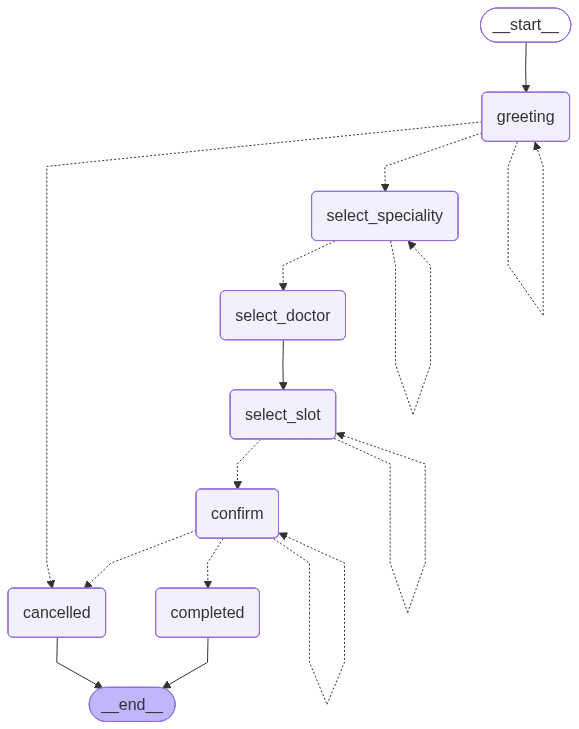

In [19]:
from IPython.display import Image, display

png_bytes = booking_graph.get_graph().draw_mermaid_png()
display(Image(png_bytes))

In [20]:
# Cell 1: Setup
from langgraph.checkpoint.memory import MemorySaver

# Initialize your graph and memory
memory = MemorySaver()
booking_graph = build_booking_graph() # This assumes your graph building function is defined

# Define config globally
config = {"configurable": {"thread_id": "test_new_02"}}

In [21]:
create_initial_state()

{'messages': [],
 'stage': 'greeting',
 'selected_speciality': None,
 'selected_doctor': None,
 'selected_slot': None,
 'customer_name': None,
 'customer_phone': None,
 'booking_id': None,
 'available_options': []}

In [22]:
from langgraph.types import Command

def run_booking_session(graph, thread_id="test_session_14", reset=False):
    config = {"configurable": {"thread_id": thread_id}}

    # 1. Start or Reset logic
    current_state = graph.get_state(config)
    if reset or not current_state.values:
        print(f"--- {'🔄 Resetting' if reset else '🆕 Initializing'} Session ---")
        # Using invoke() here kicks off the 'greeting' node immediately
        graph.invoke(create_initial_state(), config=config)

    print("---⚕⚕ Starting CarePlus Booking Session ---")
    
    last_displayed_message_idx = -1  # Track which messages have been displayed

    while True:
        state = graph.get_state(config)
        
        # Display any new assistant messages that haven't been shown yet
        # (This handles guardrail/off-topic responses)
        if state.values and state.values.get('messages'):
            messages = state.values['messages']
            for idx in range(last_displayed_message_idx + 1, len(messages)):
                msg = messages[idx]
                if msg.get("role") == "assistant":
                    print(f"\n[AI]: {msg['content']}")
            last_displayed_message_idx = len(messages) - 1

        # 2. Check for Interrupts
        if state.tasks and state.tasks[0].interrupts:
            interrupt_info = state.tasks[0].interrupts[0].value

            # --- FIX: Safely handle both String and Dict interrupts ---
            if isinstance(interrupt_info, dict):
                ai_message = interrupt_info.get('content', 'No message content')
                options = interrupt_info.get('available_options', [])
            else:
                ai_message = interrupt_info
                options = []

            print(f"\n[AI]: {ai_message}")
            if options:
                print(f"Options: {', '.join(options)}")
            # -------------------------------------------------------

            user_input = input("\n[YOU]: ")
            print(f"[YOU]: {user_input}")

            # Resume the graph with the user's input
            graph.invoke(Command(resume=user_input), config=config)

        # 3. Check if the graph has finished
        elif not state.next:
            # Before ending, check if there's a final assistant message to print
            if state.values and state.values.get('messages') and state.values['messages'][-1]["role"] == "assistant":
                if last_displayed_message_idx < len(state.values['messages']) - 1:
                    print(f"\n[AI]: {state.values['messages'][-1]['content']}")
            print("\n--- ⚑⚑ Session Ended ---")
            break

        # 4. If nodes are pending but no interrupt, let them run (the gas pedal)
        else:
            graph.invoke(None, config=config)

# IMPORTANT: Set reset=True only when you want to wipe the history.
# Set it to False to actually continue the conversation!
run_booking_session(booking_graph, reset=True)

--- 🔄 Resetting Session ---
---⚕⚕ Starting CarePlus Booking Session ---

[AI]: 👋 Welcome to CarePlus! Would you like to book an appointment?
[YOU]: Yes
LLM response: no
LLM response: I appreciate your response! If you’d like to continue with booking an appointment, I’m here to help.

[AI]: 👋 Welcome to CarePlus! Would you like to book an appointment?
[YOU]: Yes
LLM response: no
LLM response: I appreciate your response! If you’d like to continue with booking an appointment, I’m here to help.

[AI]: 👋 Welcome to CarePlus! Would you like to book an appointment?
[YOU]: Yes please book
LLM response: yes
LLM response: select_speciality

[AI]: Please choose a speciality:
Options: General Physician, Dermatologist, Orthopedic, Pediatrician, ENT Specialist
[YOU]: General Physiscian
LLM response: General Physician
LLM response: yes

[AI]: We have General Physician, Dr. Anil Sharma. Pick a slot: 10:00 AM, 11:00 AM, 12:00 PM, 1:00 PM
Options: 10:00 AM, 11:00 AM, 12:00 PM, 1:00 PM
[YOU]: What's my s

In [ ]:
from langgraph.types import Command

def run_booking_session(graph, thread_id="test_session_14", reset=False):
    config = {"configurable": {"thread_id": thread_id}}

    # 1. Start or Reset logic
    current_state = graph.get_state(config)
    if reset or not current_state.values:
        print(f"--- {'🔄 Resetting' if reset else '🆕 Initializing'} Session ---")
        # Using invoke() here kicks off the 'greeting' node immediately
        graph.invoke(create_initial_state(), config=config)

    print("---⚕⚕ Starting CarePlus Booking Session ---")
    
    last_displayed_message_idx = -1  # Track which messages have been displayed

    while True:
        state = graph.get_state(config)
        
        # Display any new assistant messages that haven't been shown yet
        # (This handles guardrail/off-topic responses)
        if state.values and state.values.get('messages'):
            messages = state.values['messages']
            for idx in range(last_displayed_message_idx + 1, len(messages)):
                msg = messages[idx]
                if msg.get("role") == "assistant":
                    print(f"\n[AI]: {msg['content']}")
            last_displayed_message_idx = len(messages) - 1

        # 2. Check for Interrupts
        if state.tasks and state.tasks[0].interrupts:
            interrupt_info = state.tasks[0].interrupts[0].value

            # --- FIX: Safely handle both String and Dict interrupts ---
            if isinstance(interrupt_info, dict):
                ai_message = interrupt_info.get('content', 'No message content')
                options = interrupt_info.get('available_options', [])
            else:
                ai_message = interrupt_info
                options = []

            print(f"\n[AI]: {ai_message}")
            if options:
                print(f"Options: {', '.join(options)}")
            # -------------------------------------------------------

            user_input = input("\n[YOU]: ")
            print(f"[YOU]: {user_input}")

            # Resume the graph with the user's input
            graph.invoke(Command(resume=user_input), config=config)

        # 3. Check if the graph has finished
        elif not state.next:
            # Before ending, check if there's a final assistant message to print
            if state.values and state.values.get('messages') and state.values['messages'][-1]["role"] == "assistant":
                if last_displayed_message_idx < len(state.values['messages']) - 1:
                    print(f"\n[AI]: {state.values['messages'][-1]['content']}")
            print("\n--- ⚑⚑ Session Ended ---")
            break

        # 4. If nodes are pending but no interrupt, let them run (the gas pedal)
        else:
            graph.invoke(None, config=config)

# IMPORTANT: Set reset=True only when you want to wipe the history.
# Set it to False to actually continue the conversation!
run_booking_session(booking_graph, reset=True)